# Importing Libraries

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Preprocess data

Load Data from sklearn

In [19]:
wine = load_wine()

X = wine.data
y = wine.target

print(X.shape)

(178, 13)


Convert data into DataFrame to check if there is null values or duplicated values

In [20]:
df = pd.DataFrame(wine.data, columns = wine.feature_names)
df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [21]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


there is no null values

In [22]:
df.duplicated().sum()

np.int64(0)

there is no duplicates

Scalling Data using StandardScaler

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

K-Means (Before PCA)

Elbow method to determine the optimal number of clusters

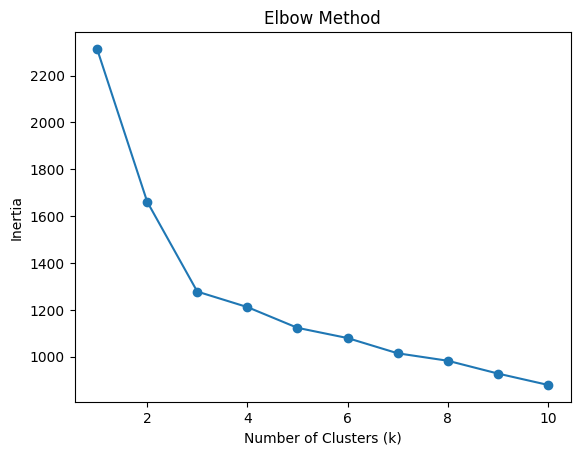

In [24]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=3)

clusters = kmeans.fit_predict(X_scaled)

In [26]:
print('Silhouette Score:', silhouette_score(X_scaled, clusters))


Silhouette Score: 0.2848589191898987


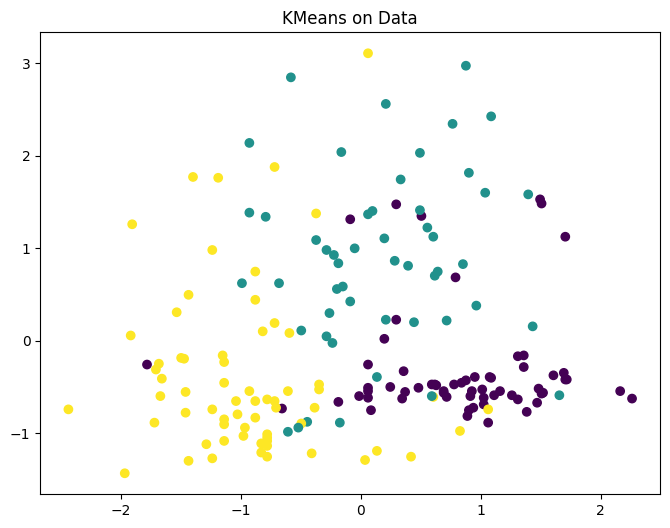

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap="viridis")
plt.title("KMeans on Data")
plt.show()

Applying PCA

In [28]:
pca = PCA(n_components=4)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(178, 4)


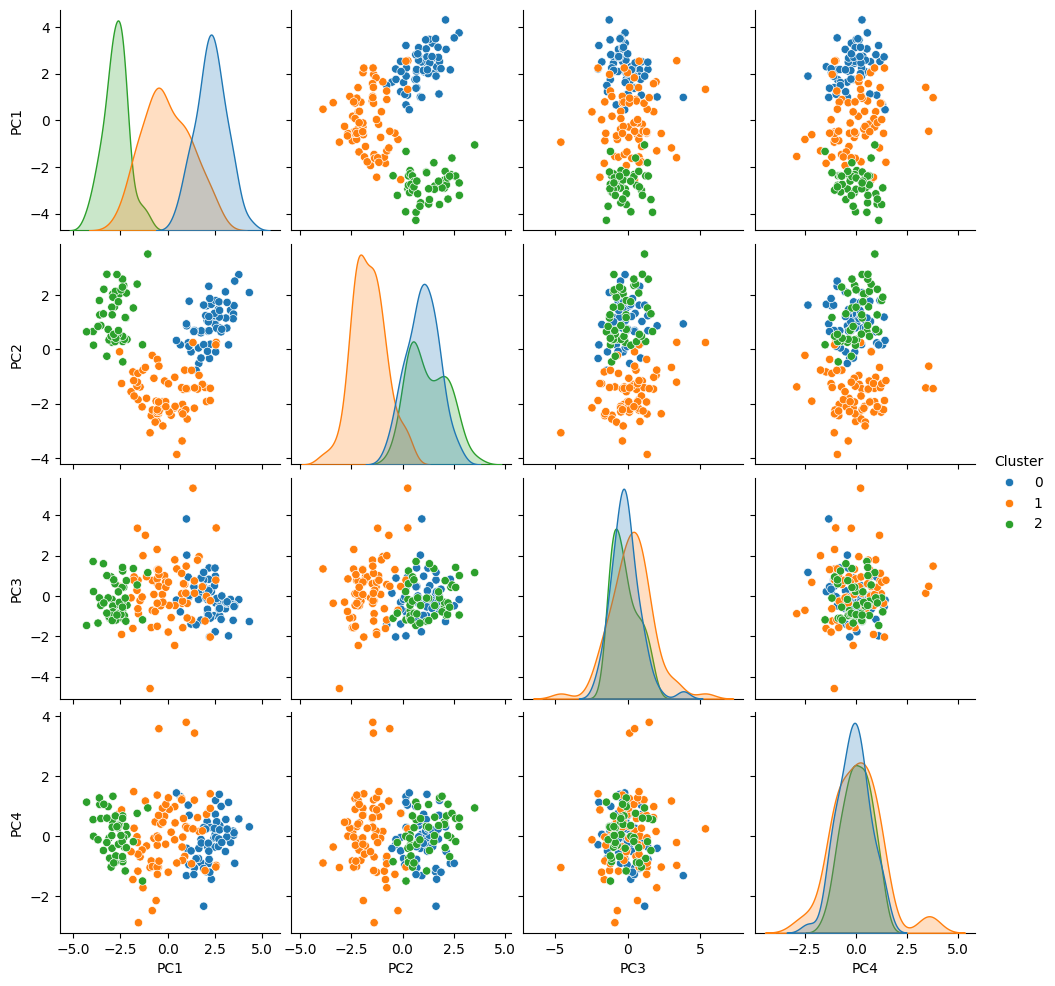

In [29]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3", "PC4"])
pca_df["Cluster"] = y

sns.pairplot(
    pca_df,
    vars=["PC1", "PC2", "PC3", "PC4"],
    hue="Cluster",
    palette="tab10"
)

plt.show()

K-Means After PCA

In [30]:
kmeans = KMeans(n_clusters=3)

clusters = kmeans.fit_predict(X_pca)

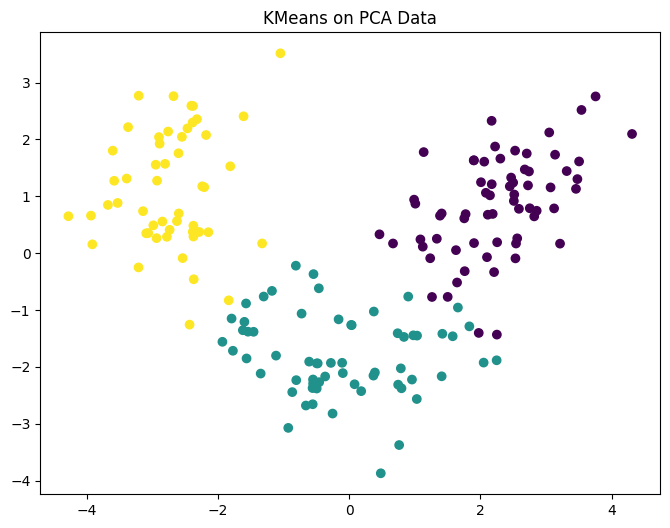

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.title("KMeans on PCA Data")
plt.show()

In [32]:
print('Silhouette Score:', silhouette_score(X_pca, clusters))

Silhouette Score: 0.40659691089486616


Check if I lost Any Important Features

In [33]:
print(f"Variance explained by 4 components: {pca.explained_variance_ratio_.sum():.2%}")

Variance explained by 4 components: 73.60%


In [34]:
print(f"Original shape: {X.shape}")
print(f"After PCA: {X_pca.shape}")

Original shape: (178, 13)
After PCA: (178, 4)


How did PCA affect clustering results?

Did visualization become clearer?

Did you lose important information?

Which approach is better and why?

How did PCA affect clustering results?

PCA improved the visualization and interpretation of the clustering results by reducing the dataset from 13 features to 4 principal components while retaining 73.60% of the original variance. The first two principal components (PC1 and PC2) clearly separated the three clusters, indicating that the most important information for clustering was preserved. Although PCA discarded 26.40% of the total variance, the clusters remained well defined with only minor overlap. Therefore, PCA reduced the dimensionality without significantly affecting the clustering structure, making the clusters easier to visualize and analyze.


---
Did visualization become clearer?


Yes, it became more clearer



---

Did you lose important information


Yes, PCA resulted in the loss of 26.40% of the total variance. However, since the first four principal components retained 73.60% of the variance and the clusters remained well separated, the information loss did not significantly impact the clustering results.



---

Which approach is better and why?

The PCA-based approach is better because it produced a higher silhouette score, indicating better cluster separation and compactness. Despite reducing the data to four principal components and retaining 73.60% of the variance, PCA preserved the important information for clustering while removing noise and redundant features, leading to improved clustering performance.


BOUNS

In [42]:
db = DBSCAN(eps=0.2, min_samples=3)

clusters_db = db.fit_predict(X_pca)

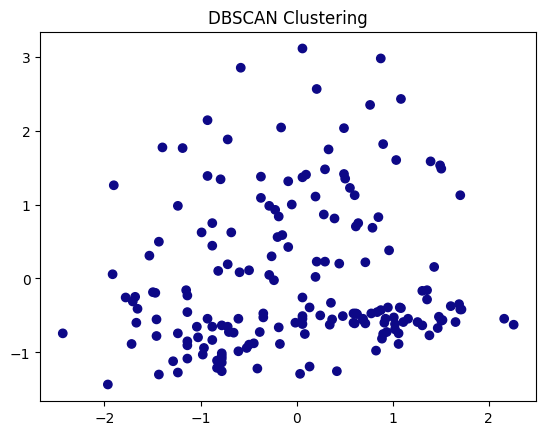

In [43]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_db, cmap="plasma")
plt.title("DBSCAN Clustering")
plt.show()

In [44]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.281934318180331
